In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install ultralytics --upgrade


  Using cached ultralytics-8.3.138-py3-none-any.whl.metadata (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-

In [3]:
import yaml

# Load original data.yaml
yaml_path = "/kaggle/input/forest-fire-v8/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Fix the paths (use absolute paths for Kaggle)
data['train'] = '/kaggle/input/forest-fire-v8/train'
data['val'] = '/kaggle/input/forest-fire-v8/valid'
# Optional: test path if you want to evaluate
data['test'] = '/kaggle/input/forest-fire-v8/test'

# Save the new YAML file to working directory
new_yaml_path = '/kaggle/working/data.yaml'

with open(new_yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Updated data.yaml saved at:", new_yaml_path)


Updated data.yaml saved at: /kaggle/working/data.yaml


In [4]:
import yaml

yaml_path = "/kaggle/working/data.yaml"

# Open and load the YAML file
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Print contents
print("YAML contents:")
print(data)

YAML contents:
{'names': ['fire'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'wildfire-yh86l', 'url': 'https://universe.roboflow.com/mini-z0ruz/wildfire-yh86l/dataset/2', 'version': 2, 'workspace': 'mini-z0ruz'}, 'test': '/kaggle/input/forest-fire-v8/test', 'train': '/kaggle/input/forest-fire-v8/train', 'val': '/kaggle/input/forest-fire-v8/valid'}


In [8]:
from ultralytics import YOLO
from IPython.display import Image


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
!yolo task=detect mode=train data=/kaggle/working/data.yaml model="yolov8n.pt" epochs=50 imgsz=640

100%|██████████████████████████████████████| 6.25M/6.25M [00:00<00:00, 80.5MB/s]
Ultralytics 8.3.138 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.55_c35c524a.jpg: 448x640 1 fire, 7.7ms
Speed: 1.5ms preprocess, 7.7ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


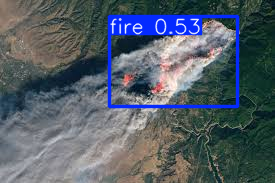


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_00faf898.jpg: 448x640 (no detections), 6.0ms
Speed: 1.6ms preprocess, 6.0ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


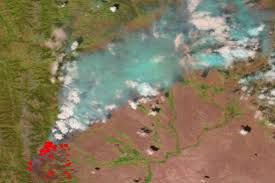


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_5bd5a6b1.jpg: 384x640 2 fires, 6.7ms
Speed: 1.2ms preprocess, 6.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


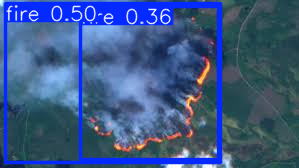


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_b1d7bdce.jpg: 288x640 2 fires, 7.2ms
Speed: 1.4ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 640)


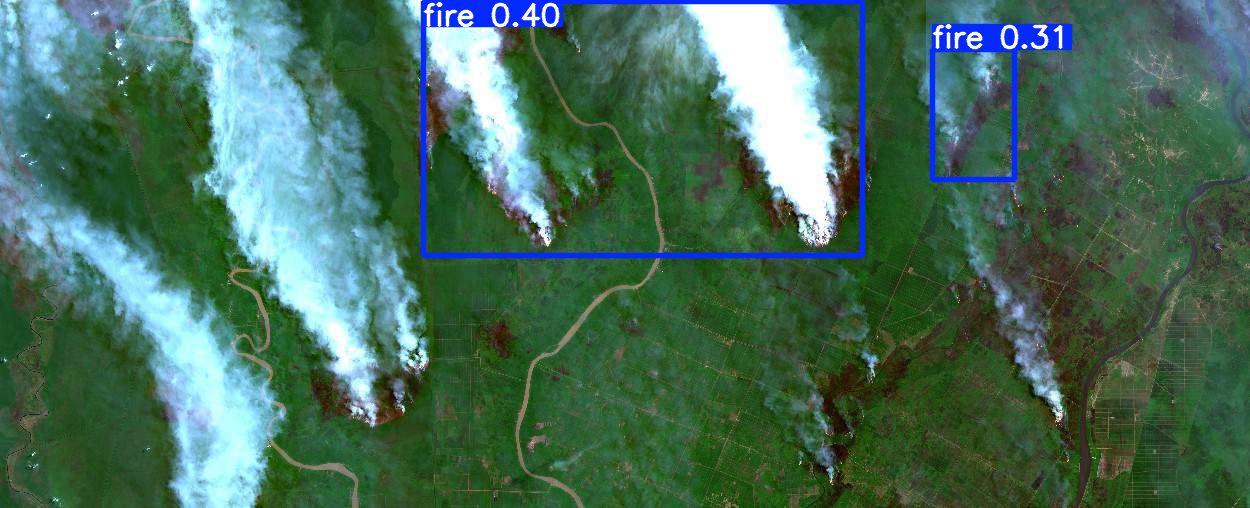

In [11]:
from ultralytics import YOLO

# Load the trained model
# IT IS STORED IN THE FOLLOWING VALIDATION FOLDER NAMED Validating runs/detect/train/weights/best.pt.
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

results = model("/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.55_c35c524a.jpg")
results[0].show()

results = model("/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_00faf898.jpg")
results[0].show()

results = model("/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_5bd5a6b1.jpg")
results[0].show()

results = model("/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_b1d7bdce.jpg")
results[0].show()

In [12]:
import pandas as pd
df = pd.read_csv('/kaggle/working/runs/detect/train/results.csv')
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,40.0378,1.78344,2.69028,1.81020,0.24668,0.27113,0.15996,0.05960,2.04045,3.04835,2.57922,0.000663,0.000663,0.000663
1,2,75.0776,1.82425,2.41404,1.82349,0.16297,0.27817,0.12353,0.04188,2.19082,3.36862,2.43294,0.001304,0.001304,0.001304
2,3,109.5340,1.82243,2.32440,1.83188,0.31316,0.33099,0.25592,0.12027,2.04935,2.49681,2.31190,0.001918,0.001918,0.001918
3,4,144.2940,1.80706,2.25298,1.81542,0.21696,0.34155,0.21506,0.08348,2.19844,2.64456,2.44460,0.001881,0.001881,0.001881
4,5,179.5840,1.75145,2.20008,1.76642,0.33443,0.32394,0.25219,0.11519,1.96112,2.53303,2.24419,0.001842,0.001842,0.001842


F1 Curve:


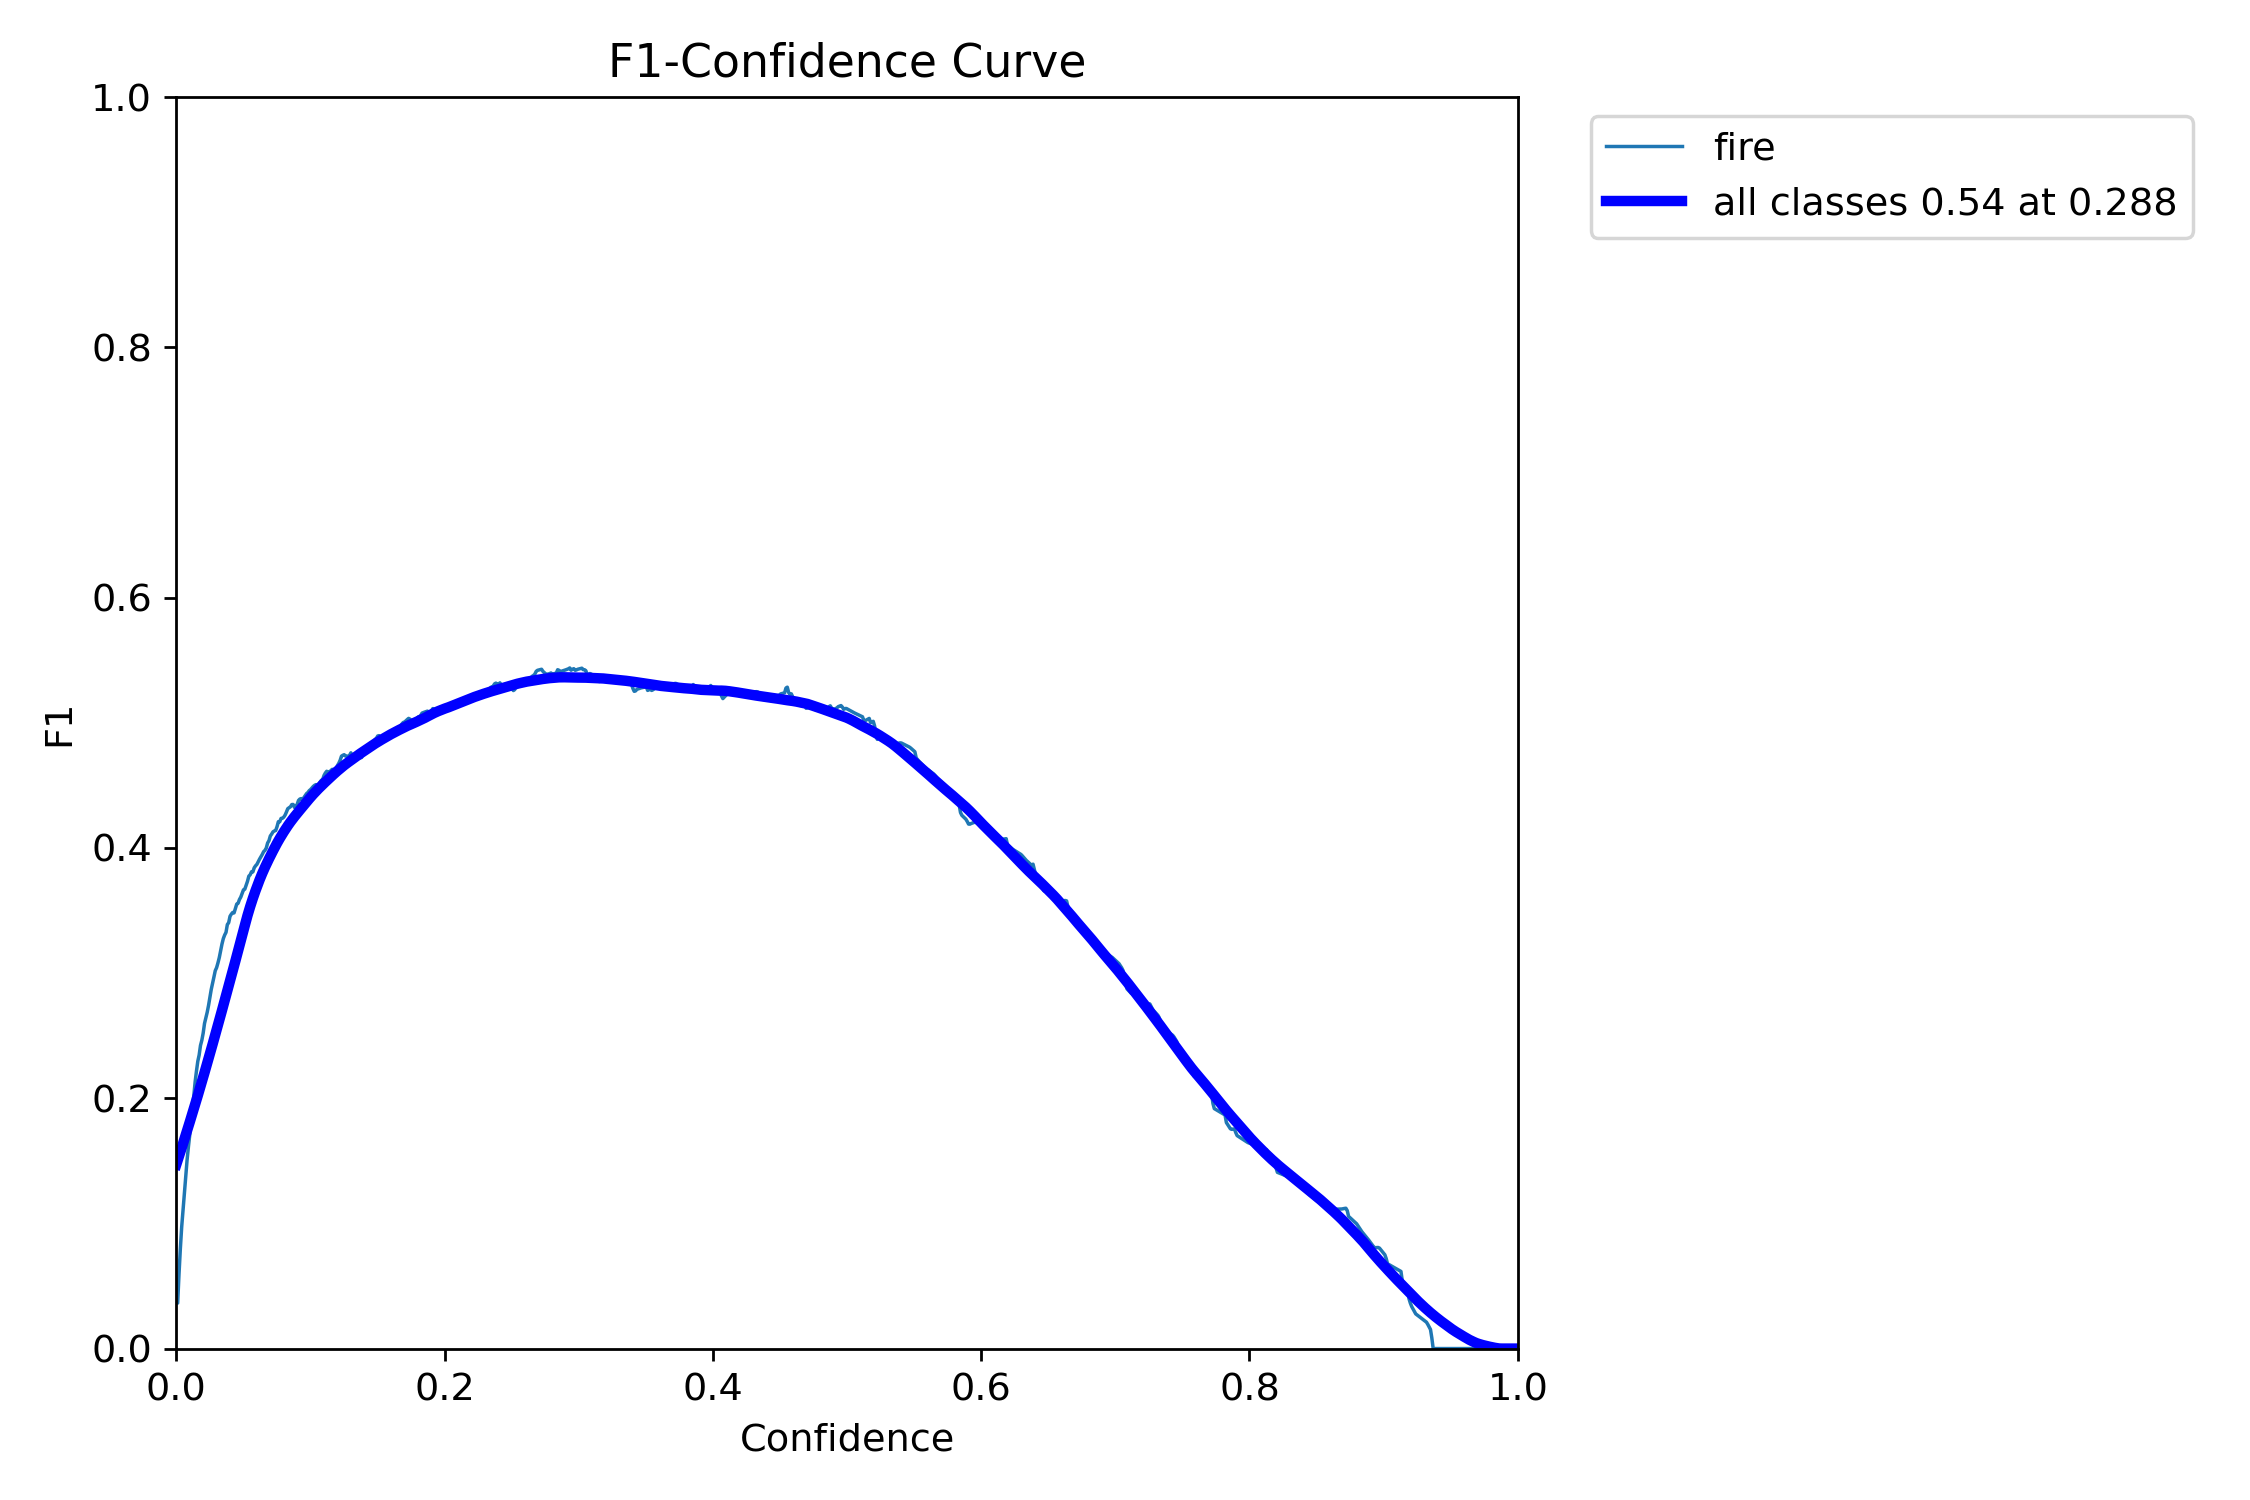

In [13]:
print("F1 Curve:")
display(Image(filename='/kaggle/working/runs/detect/train/F1_curve.png'))

Precision-Recall Curve:


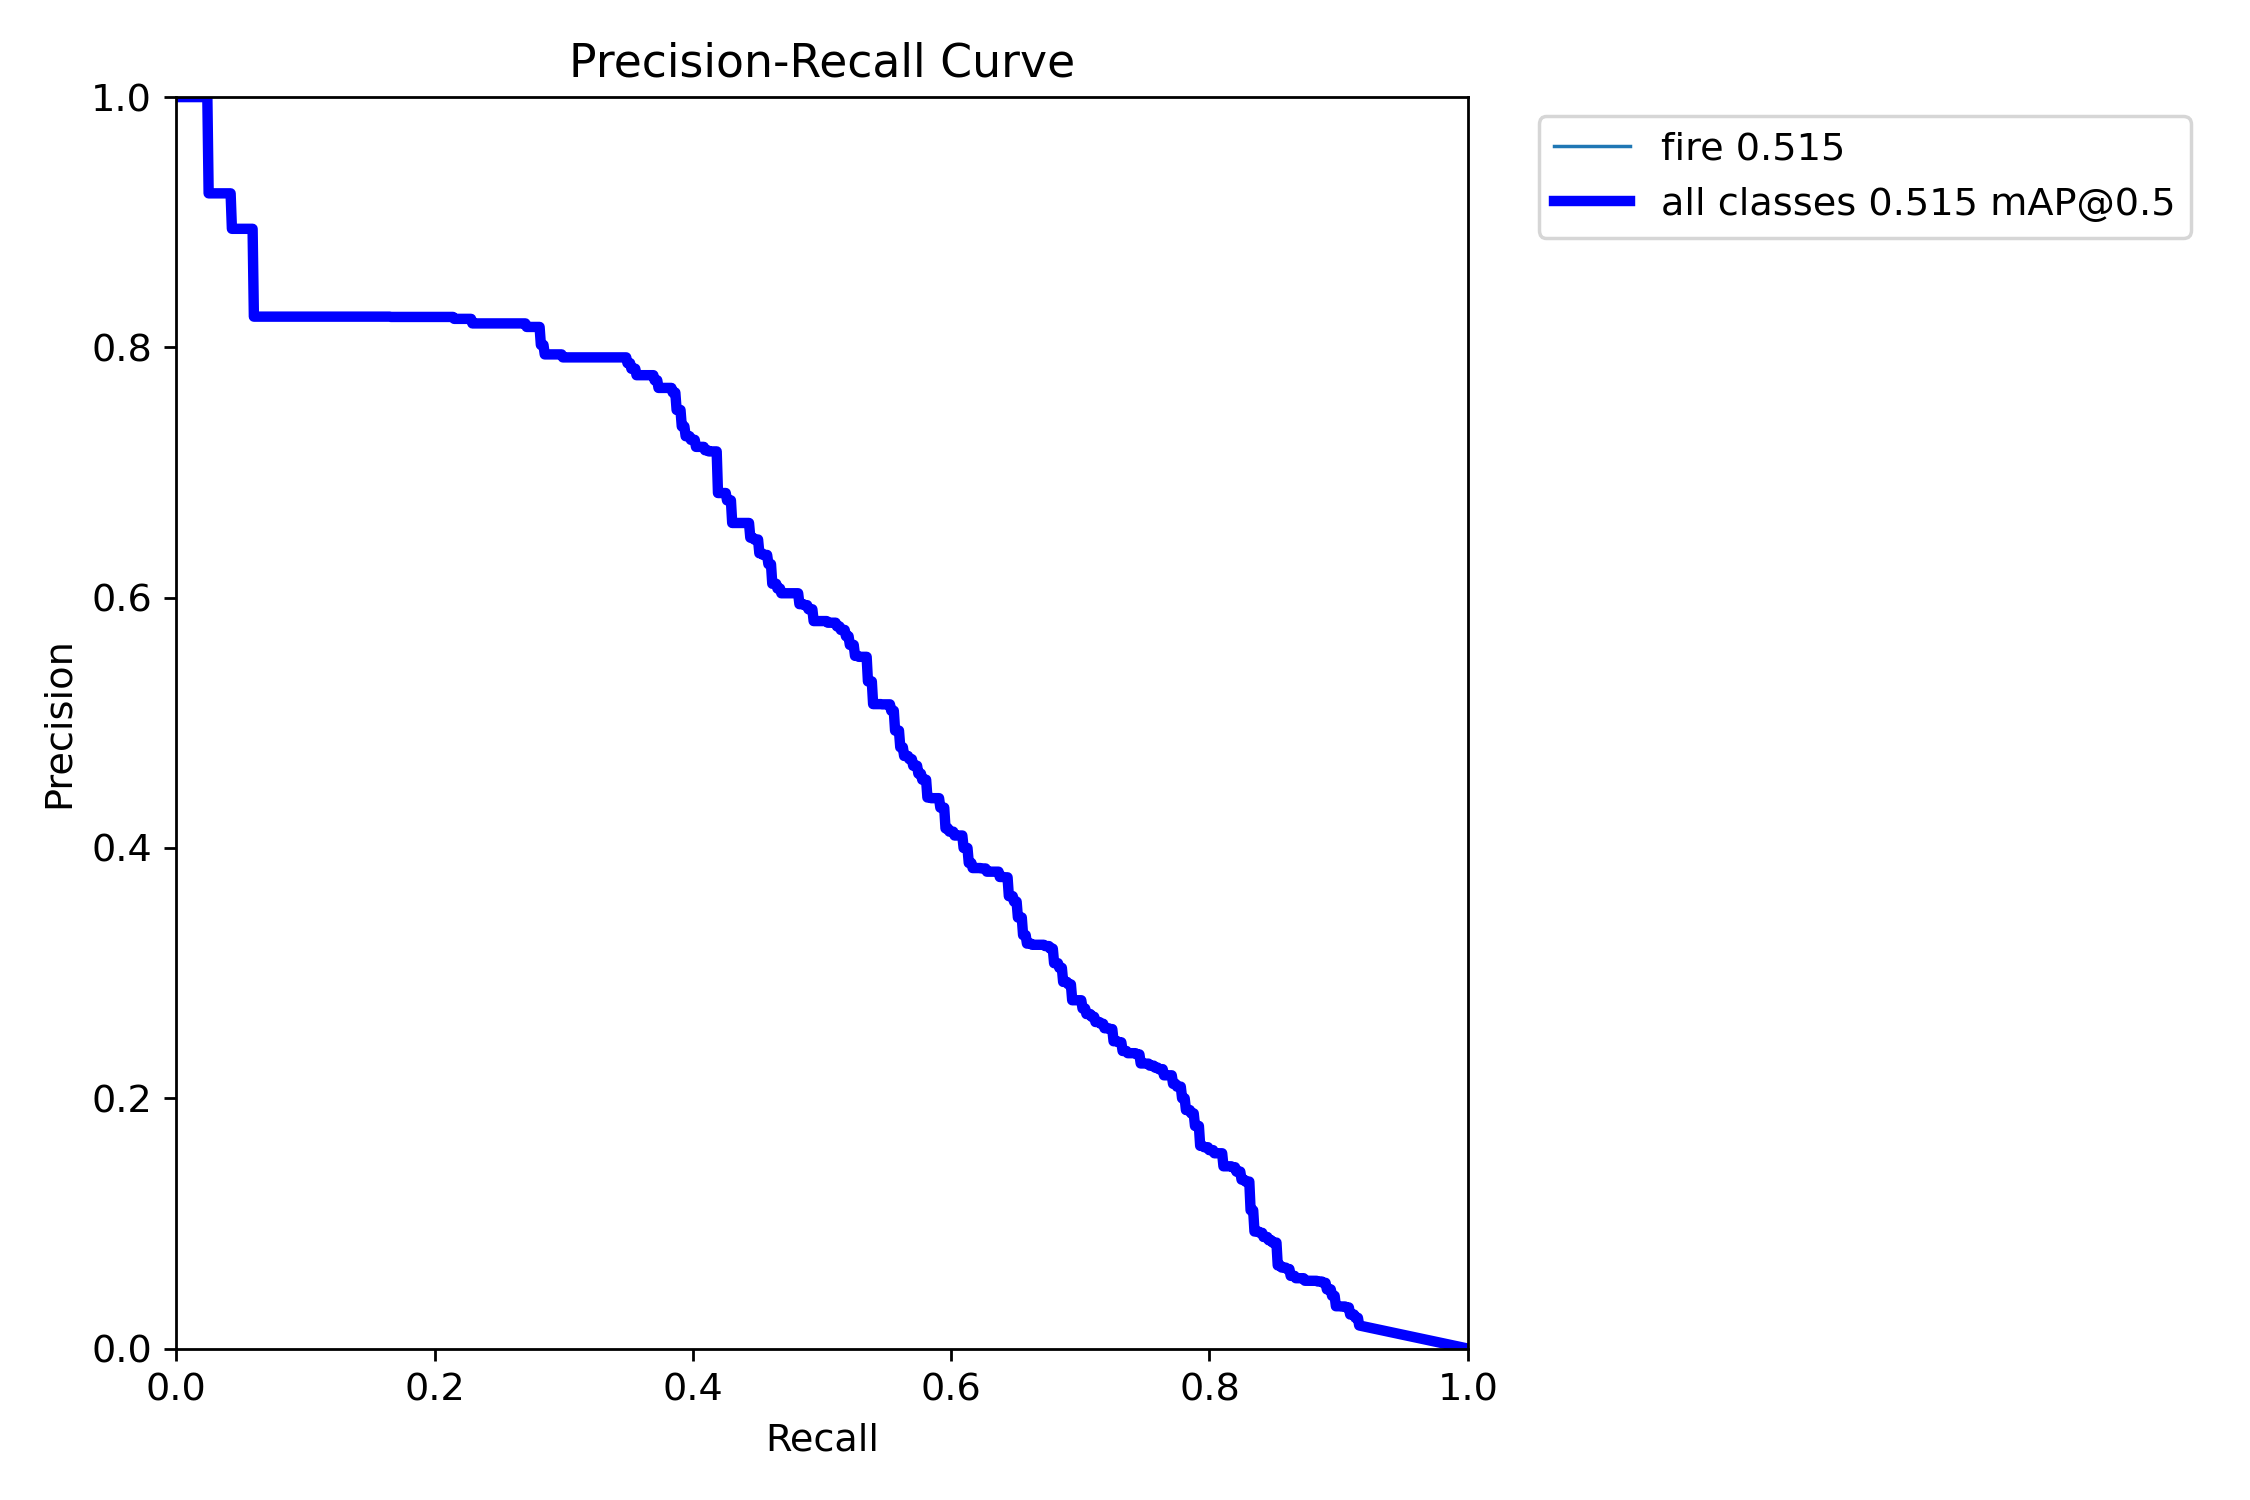

In [14]:
print("Precision-Recall Curve:")
display(Image(filename='/kaggle/working/runs/detect/train/PR_curve.png'))

Confusion Matrix:


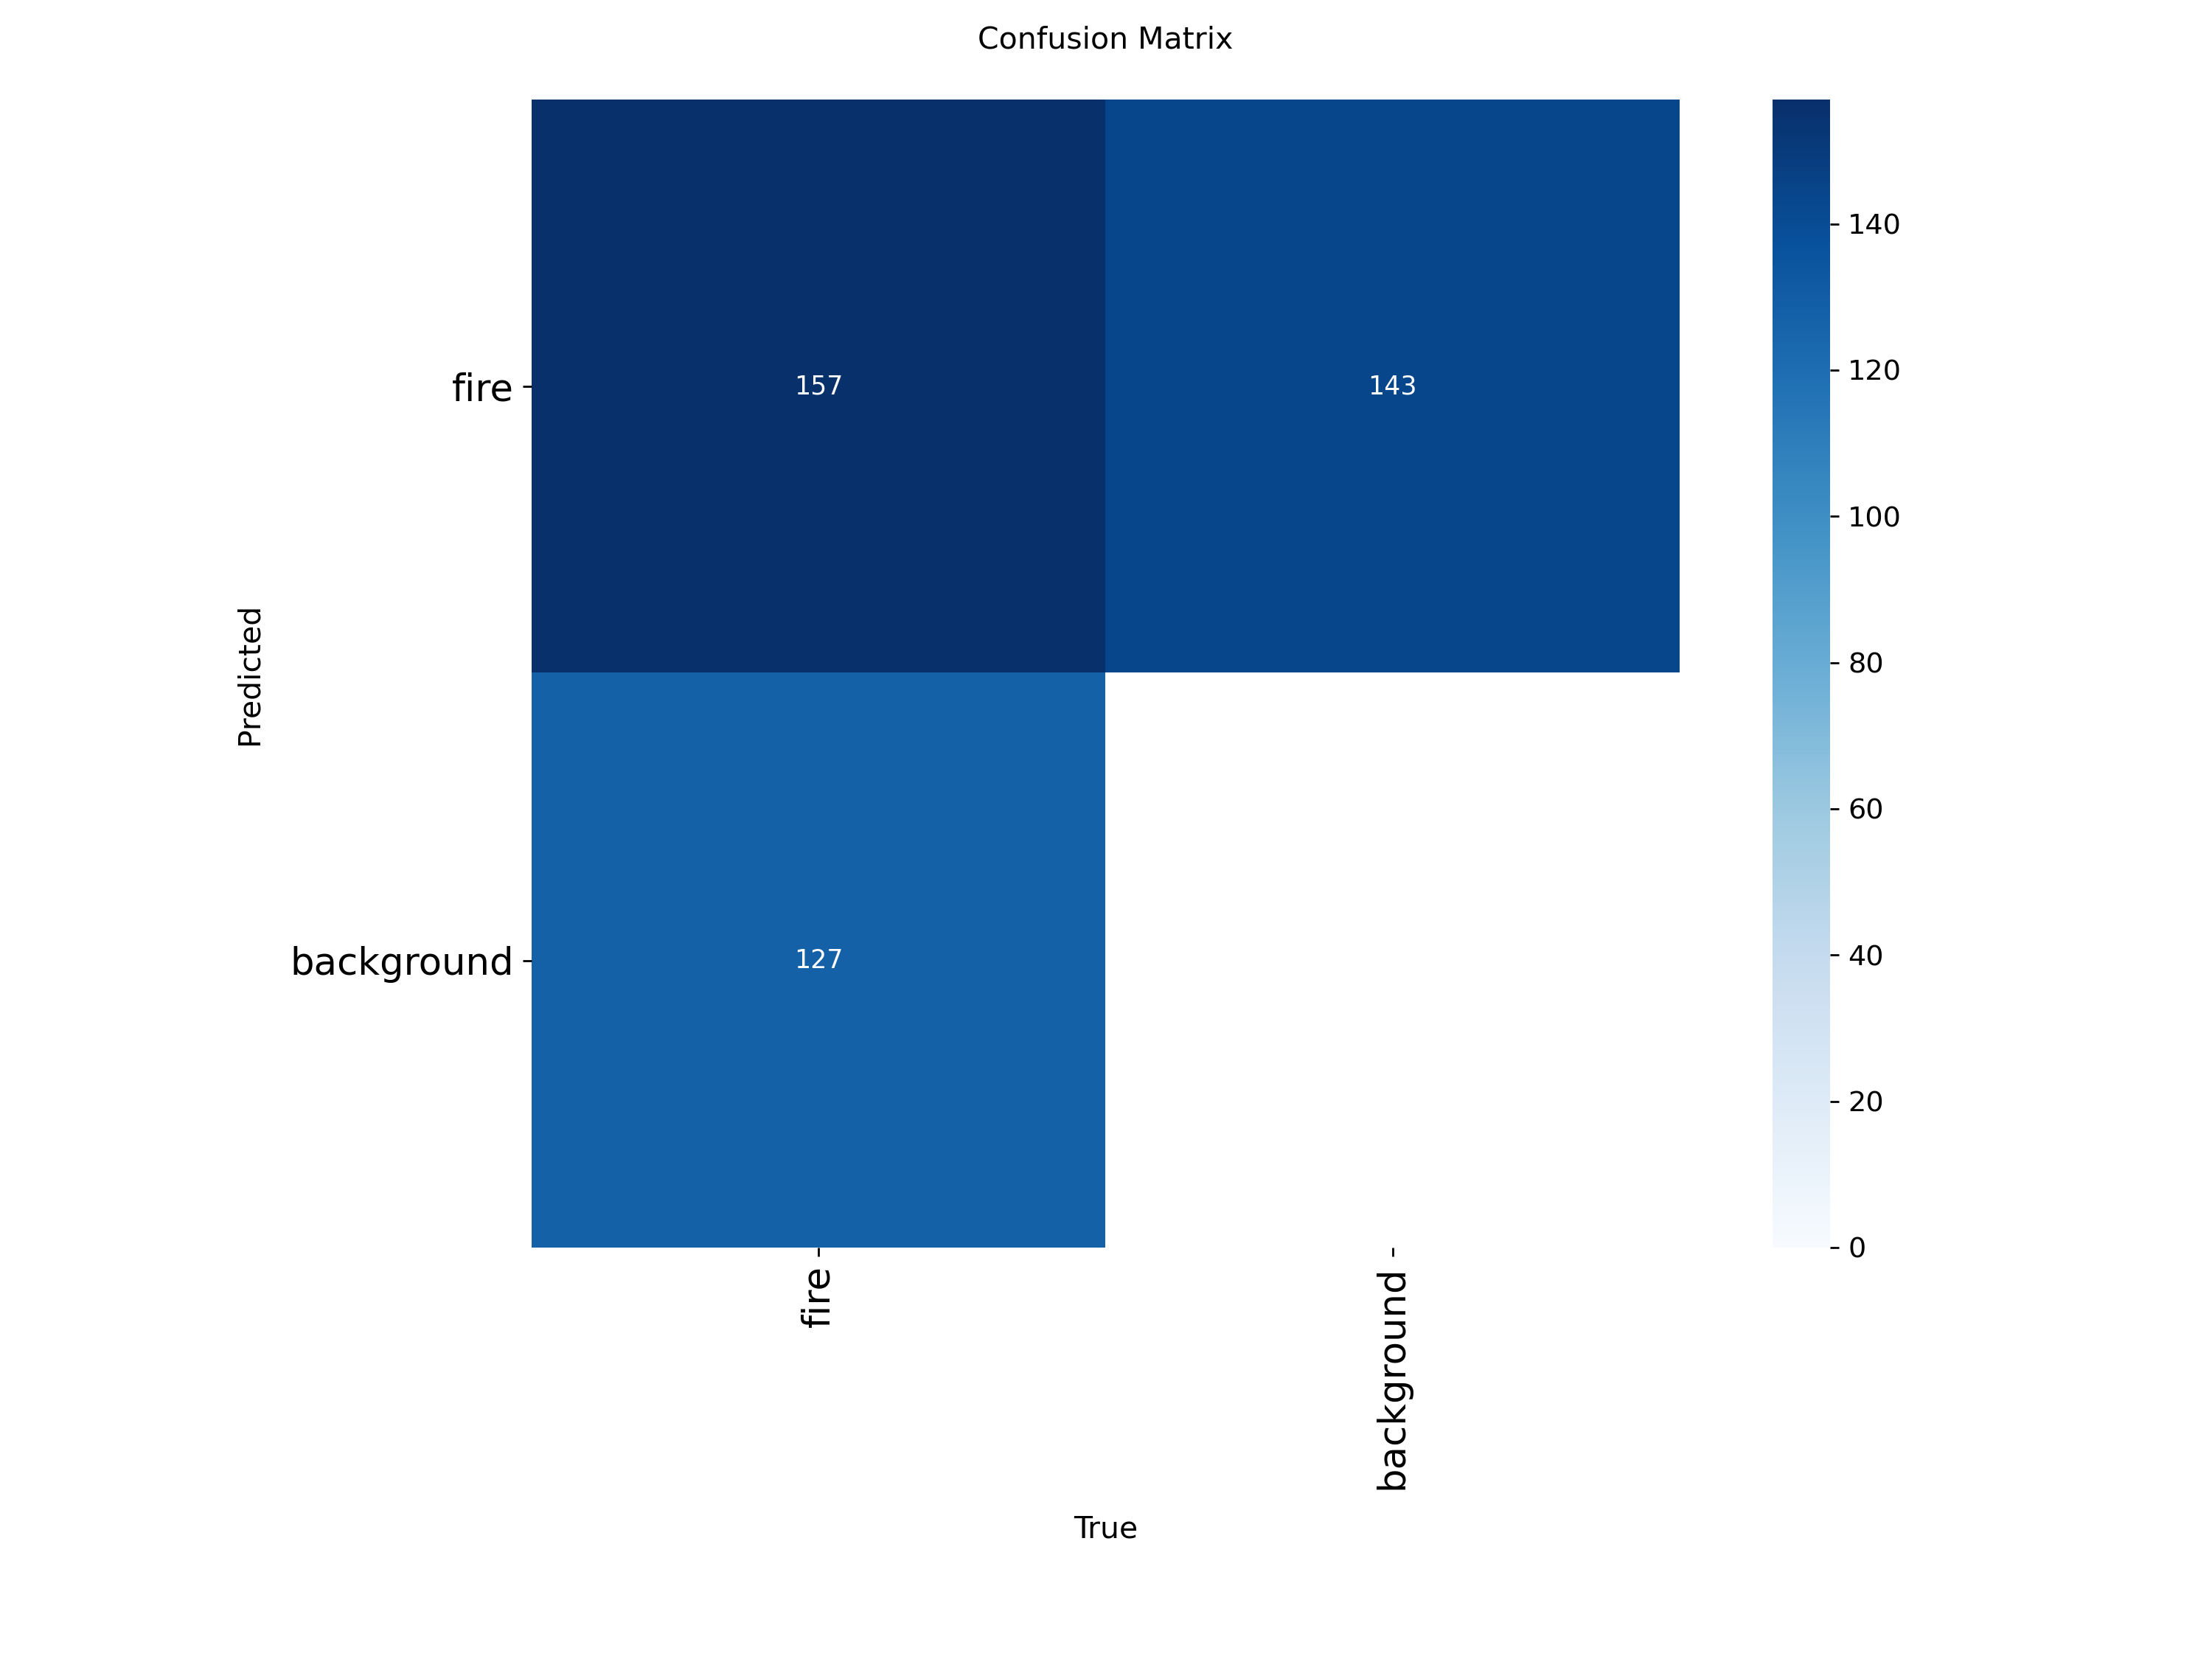

In [15]:
print("Confusion Matrix:")
display(Image(filename='/kaggle/working/runs/detect/train/confusion_matrix.png'))

Training Results:


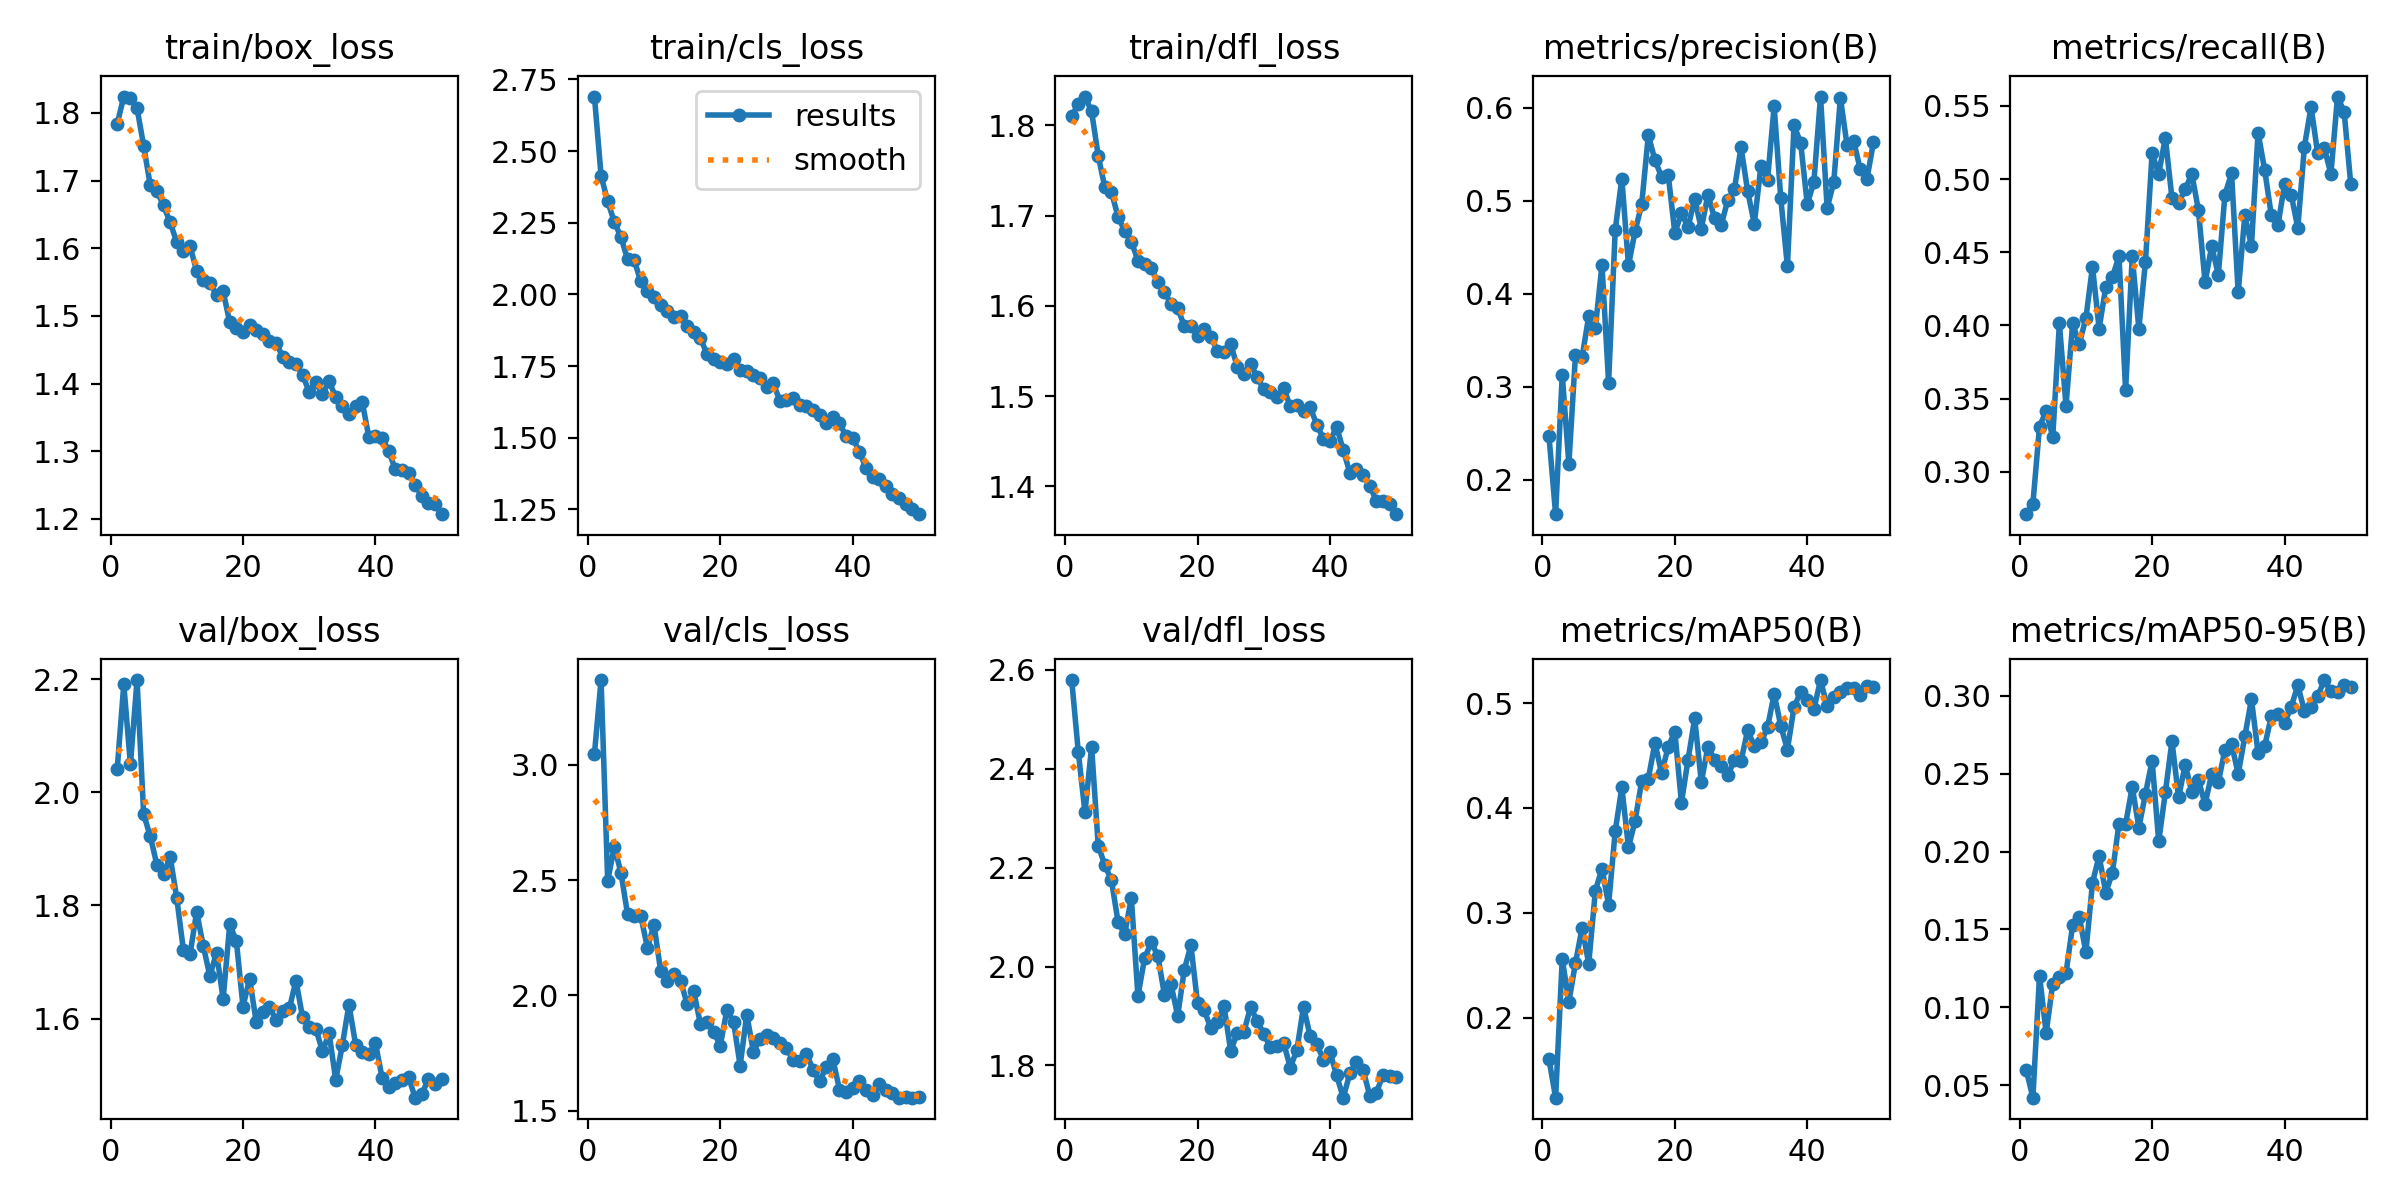

In [16]:
print("Training Results:")
display(Image(filename='/kaggle/working/runs/detect/train/results.png'))

In [17]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.55_c35c524a.jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.55_c35c524a.jpg: 448x640 1 fire, 6.8ms
Speed: 2.3ms preprocess, 6.8ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)
Latency: 116.03 ms


In [18]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_00faf898.jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_00faf898.jpg: 448x640 (no detections), 6.6ms
Speed: 1.7ms preprocess, 6.6ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Latency: 92.83 ms


In [20]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_5bd5a6b1.jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_5bd5a6b1.jpg: 384x640 2 fires, 7.1ms
Speed: 1.5ms preprocess, 7.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Latency: 95.72 ms


In [19]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_b1d7bdce.jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fire-img/images/WhatsApp Image 2025-05-18 at 12.23.56_b1d7bdce.jpg: 288x640 2 fires, 7.0ms
Speed: 1.4ms preprocess, 7.0ms inference, 1.5ms postprocess per image at shape (1, 3, 288, 640)
Latency: 105.31 ms
